In [1]:
from pathlib import Path
import sys
import os

# Add parent directory to Python path
project_root = Path("/home/nbyrnes/code/random-matrix/")  # <-- adjust this
sys.path.insert(0, str(project_root))

import pickle
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.sparse
import shapely
import tqdm
import quadpy
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.input_statistics.matrix_pool_manager import (
    MatrixPoolManager,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler
import cupy as cp
import math
from tqdm import tqdm
from shapely.geometry import Point, Polygon
from scipy.signal import czt
from random_matrix.utils import geometry_utils as sg

In [2]:
# Some useful functions


def get_e_theta_phi(
    k_x: np.ndarray | cp.ndarray,
    k_y: np.ndarray | cp.ndarray,
    k_z: np.ndarray | cp.ndarray,
) -> tuple[np.ndarray | cp.ndarray, np.ndarray | cp.ndarray]:
    """Get the theta and phi spherical polar basis vectors associated with
    a plane wave with given wavevector. The wavevector is assumed to be
    normalized."""
    xp = sg.array_utils.get_module(k_x)

    mod_kappa = xp.sqrt((k_x**2 + k_y**2))

    # Find indices where k is parallel to z
    bad_indices = xp.where(xp.isclose(mod_kappa, 0.0))
    num_bad_indices = len(bad_indices[0])

    # Do the cross product and normalize (e_phi = z cross k)
    e_phi = xp.empty((*k_x.shape, 3))
    e_phi[..., 0] = k_y
    e_phi[..., 1] = -k_x
    e_phi[..., 2] = 0.0
    e_phi /= mod_kappa[..., xp.newaxis]
    e_phi[bad_indices] = xp.column_stack(
        (
            xp.zeros(num_bad_indices),
            k_z[bad_indices],
            xp.zeros(num_bad_indices),
        )
    )

    # e_theta = e_phi cross k
    e_theta = xp.empty((*k_x.shape, 3))
    e_theta[..., 0] = k_x * k_z
    e_theta[..., 1] = k_y * k_z
    e_theta[..., 2] = -(mod_kappa**2)

    # e_theta /= (mod_kappa[..., xp.newaxis]*kz)
    e_theta /= xp.sqrt(
        e_theta[..., 0] ** 2 + e_theta[..., 1] ** 2 + e_theta[..., 2] ** 2
    )[..., xp.newaxis]
    e_theta[bad_indices] = xp.column_stack(
        (
            xp.ones(num_bad_indices),
            xp.zeros(num_bad_indices),
            xp.zeros(num_bad_indices),
        )
    )
    return e_theta, e_phi


def multi_plot_grid(
    my_grid: mode_grid, fields: np.ndarray, titles: list[str] | None = None
):
    """
    Plot the scattered field intensities on the mode grid using an adaptive grid.

    If num_plots > 2, the function makes additional rows automatically.
    """

    num_plots, _ = fields.shape
    if titles is None:
        titles = [""] * num_plots

    # --- Layout rules ---
    max_cols = 3  # max number of plots per row
    ncols = min(max_cols, num_plots)
    nrows = math.ceil(num_plots / max_cols)

    # Adaptive figure size
    fig_width = max(7, 4 * ncols)
    fig_height = max(5, 4 * nrows)
    fig, axs = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height))

    # Normalize axs to a 2D array for easy indexing
    if nrows == 1:
        axs = np.array([axs])
    if ncols == 1:
        axs = axs.reshape(nrows, 1)

    vertices_list = [mode.vertices for mode in my_grid.propagating_modes_list]

    # Shared color limits
    vmin, vmax = np.min(fields), np.max(fields)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.jet

    # Flatten for easy iteration
    axs_flat = axs.flatten()

    for idx, (field, ax) in enumerate(zip(fields, axs_flat)):
        for i, vertices in enumerate(vertices_list):
            polygon = plt.Polygon(
                vertices, color=cmap(norm(field[i])), alpha=0.85
            )
            ax.add_patch(polygon)

        ax.axhline(0, color="black", lw=0.6)
        ax.axvline(0, color="black", lw=0.6)

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("$k_x$")
        ax.set_ylabel("$k_y$")
        ax.set_title(titles[idx])

    # Turn off unused axes if num_plots < nrows*ncols
    for j in range(num_plots, nrows * ncols):
        axs_flat[j].axis("off")

    # ----- Shared colorbar -----
    # Create a dedicated colorbar axis
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    fig.colorbar(sm, cax=cbar_ax)

    fig.subplots_adjust(right=0.88)  # leave space for colorbar

    plt.show()


def find_mode_index_by_point(
    self, kx: float, ky: float, wave_type: str = "propagating"
) -> int | None:
    """
    Returns the index of the mode whose polygon contains or touches the given (kx, ky).

    Parameters
    ----------
    kx : float
        kx coordinate
    ky : float
        ky coordinate
    wave_type : str
        "propagating" or "evanescent"

    Returns
    -------
    index : str or None
        Index of the containing/touching mode, or None if not found
    """
    point = shapely.geometry.Point(kx, ky)
    for key, mode in self.modes.items():
        if key[1] != wave_type:
            continue
        verts = np.array(mode.vertices)
        polygon = shapely.geometry.Polygon(verts)
        if polygon.contains(point) or polygon.touches(point):
            return int(key[0])
    return None


def plot_field_on_grid(
    my_grid: mode_grid, E: np.array, type: str | None = None
) -> None:
    """
    type: "S" for s-polarised field, "P" for p-polarized field
    """
    # Extract the vertices and indices of the grid
    vertices_list = [mode.vertices for mode in my_grid.propagating_modes_list]
    indices = [mode.index for mode in my_grid.mode_list]

    field_values = E
    norm = plt.Normalize(vmin=np.min(field_values), vmax=np.max(field_values))
    cmap = plt.cm.jet

    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    for i, vertices in enumerate(vertices_list):
        color = cmap(norm(field_values[i]))
        polygon = plt.Polygon(vertices, color=color, alpha=0.8)
        ax.add_patch(polygon)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal", adjustable="box")

    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(
        sm, ax=ax, orientation="vertical", pad=0.02, label="Field Intensity"
    )

    plt.xlabel("k_x")
    plt.ylabel("k_y")
    plt.title(f"$Field Visualization ({type})$")
    plt.show()


def generate_field_tp(
    indices: np.array,
    num_propagating: int,
    incident_pol: np.ndarray | None = None,
) -> np.ndarray:
    """
    Generates a set of incident field vectors for specified mode indices and polarization [Es, Ep].

    Parameters
    ----------
    indices : np.array
        List or array of mode indices where the incident field is nonzero.
    num_propagating : int
        Number of propagating modes (n). The output field vector will have length 2*n.
    incident_pol : np.ndarray or None
        Polarization vector [Es, Ep]. If None, defaults to [1, 0] (pure s-polarization).

    Returns
    -------
    E : np.ndarray
        Array of shape (num_fields, 2*num_propagating). Each row is an incident field vector
        with the specified polarization at the given mode index, and zeros elsewhere.
    """
    num_fields = len(indices)

    if incident_pol is None:
        incident_pol = np.array([np.array([1, 0]) for _ in range(num_fields)])

    n = num_propagating
    E = np.zeros((num_fields, 2 * n), dtype=complex)

    # Helper logic for index calculation (included here, not external)
    if n % 2 == 0:
        raise ValueError("n must be odd")
    half = n // 2

    for i, mode in enumerate(indices):
        if mode < -half or mode > half:
            raise ValueError(f"mode must be between {-half} and {half}")
        start = (mode + half) * 2
        E[i, start] = incident_pol[i,0]
        E[i, start + 1] = incident_pol[i,1]

    return E


def generate_field_xyz(
    indices: np.array,
    num_propagating: int,
    incident_pol: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    if incident_pol is None:
        incident_pol = np.array([1, 0, 0])

    num_fields = len(indices)
    n = num_propagating
    E = np.zeros((num_fields, 3 * n), dtype=complex)

    # Helper logic for index calculation (included here, not external)
    if n % 2 == 0:
        raise ValueError("n must be odd")
    half = n // 2

    for i, mode in enumerate(indices):
        if mode < -half or mode > half:
            raise ValueError(f"mode must be between {-half} and {half}")
        start = (mode + half) * 3
        E[i, start] = incident_pol[0]
        E[i, start + 1] = incident_pol[1]
        E[i, start + 2] = incident_pol[2]

    return E


def from_kxkykz_2_sp(
    my_grid: mode_grid, Ekx: np.ndarray, Eky: np.ndarray, Ekz: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    center_list = [mode.center for mode in my_grid.propagating_modes_list]
    centre_kx = np.array([center[0] for center in center_list])
    centre_ky = np.array([center[1] for center in center_list])
    centre_kz = np.sqrt(1 - centre_kx**2 - centre_ky**2)
    e_theta, e_phi = get_e_theta_phi(centre_kx, centre_ky, centre_kz)
    Es = []
    Ep = []
    for i in range(Ekx.shape[0]):
        # Convert to s,p components
        Es.append(
            Ekx[i, :] * (e_phi[:, 0])
            + Eky[i, :] * (e_phi[:, 1])
            + Ekz[i, :] * (e_phi[:, 2])
        )
        Ep.append(
            Ekx[i, :] * (e_theta[:, 0])
            + Eky[i, :] * (e_theta[:, 1])
            + Ekz[i, :] * (e_theta[:, 2])
        )
    return np.array(Es), np.array(Ep)


def from_sp_2_kxkykz(
    my_grid: mode_grid, Es: np.ndarray, Ep: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    center_list = [mode.center for mode in my_grid.propagating_modes_list]
    centre_kx = np.array([center[0] for center in center_list])
    centre_ky = np.array([center[1] for center in center_list])
    centre_kz = np.sqrt(1 - centre_kx**2 - centre_ky**2)
    e_theta, e_phi = get_e_theta_phi(centre_kx, centre_ky, centre_kz)
    Ekx = []
    Eky = []
    Ekz = []
    for i in range(Es.shape[0]):
        # Convert to kx,ky,kz components

        Ekx.append(Es[i, :] * (e_phi[:, 0]) + Ep[i, :] * (e_theta[:, 0]))
        Eky.append(Es[i, :] * (e_phi[:, 1]) + Ep[i, :] * (e_theta[:, 1]))
        Ekz.append(Es[i, :] * (e_phi[:, 2]) + Ep[i, :] * (e_theta[:, 2]))
    return np.array(Ekx), np.array(Eky), np.array(Ekz)

def grid_2_mesh(
    my_grid: mode_grid,
    Ekx: np.array,
    Eky: np.array,
    Ekz: np.array,
    kscale: float = 1.0,
    Nkx: int = 512,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # k range
    kmin = -kscale
    kmax = kscale
    # samples in k space
    k0 = np.linspace(kmin, kmax, Nkx)
    kx, ky = np.meshgrid(k0, k0)
    max_idx = my_grid.max_index
    min_idx = -max_idx
    Ekx_grid = np.zeros_like(kx, dtype=complex)
    Eky_grid = np.zeros_like(kx, dtype=complex)
    Ekz_grid = np.zeros_like(kx, dtype=complex)

    for idx, i in enumerate(tqdm(range(min_idx, max_idx + 1))):
        mode0 = my_grid.by_index(i)

        vertices = (mode0.vertices) * kscale
        points = np.vstack((kx.ravel(), ky.ravel())).T
        square_path = matplotlib.path.Path(vertices)
        mode = square_path.contains_points(points).reshape(kx.shape)
        # Update Ex_grid with the contribution from this mode and propagation phase
        Ekx_grid += mode * ((Ekx[idx]))
        Eky_grid += mode * ((Eky[idx]))
        Ekz_grid += mode * ((Ekz[idx]))

    return Ekx_grid, Eky_grid, Ekz_grid

def get_xyz_from_tp(
    my_grid, E_theta: np.ndarray, E_phi: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    center_list = np.array(
        [mode.center for mode in my_grid.propagating_modes_list]
    )
    centre_kx = center_list[:, 0]
    centre_ky = center_list[:, 1]
    centre_kz = np.sqrt(1.0 - centre_kx**2 - centre_ky**2)
    e_theta, e_phi = get_e_theta_phi(centre_kx, centre_ky, centre_kz)

    Ekx = []
    Eky = []
    Ekz = []
    for i in range(len(E_theta)):
        Ekx.append(E_theta[i, :] * e_theta[:, 0] + E_phi[i, :] * e_phi[:, 0])
        Eky.append(E_theta[i, :] * e_theta[:, 1] + E_phi[i, :] * e_phi[:, 1])
        Ekz.append(E_theta[i, :] * e_theta[:, 2] + E_phi[i, :] * e_phi[:, 2])
    return np.array(Ekx), np.array(Eky), np.array(Ekz)


def czt2(
    input: np.array,
    x_min: float | None = None,
    x_max: float | None = None,
    y_min: float | None = None,
    y_max: float | None = None,
    Nx: float = 512,
    Nk: float = 512,
    mode: str = "FT",
    kscale: float  = 1.0,
) -> np.array:

    if x_min == None:
        x_min = -10 * (2 * np.pi / kscale)
    if y_min == None:
        y_min = -10 * (2 * np.pi / kscale)
    if x_max == None:
        x_max = 10 * (2 * np.pi / kscale)
    if y_max == None:
        y_max = 10 * (2 * np.pi / kscale)

    x0 = np.linspace(x_min, x_max, Nx)
    y0 = np.linspace(y_min, y_max, Nx)
    # k range
    kmin = -kscale
    kmax = kscale
    # samples in k space

    k0 = np.linspace(kmin, kmax, Nk)

    a = -1
    ak = 1

    dx = abs(x0[2] - x0[1])
    dy = abs(y0[2] - y0[1])
    dkx = abs(k0[2] - k0[1])

    Wkx = np.exp(-1j * ak * dx * dkx)
    Wx = np.exp(-1j * a * dx * dkx)  # used in IFT
    Akx = np.exp(1j * ak * kmin * dx)
    Aky = np.exp(1j * ak * kmin * dy)
    Ax = np.exp(1j * a * x_min * dkx)  # used in IFT
    Ay = np.exp(1j * a * y_min * dkx)  # used in IFT
    # these factors account for the shift of origin using shift theorem
    pkx = np.exp(-ak * 1j * (x_min) * k0)
    pky = np.exp(-ak * 1j * (y_min) * k0)
    px = np.exp(-a * 1j * (kmin) * x0)
    if mode == "FT":
        row_czt = np.array(
            [dx * pkx * czt(row, Nk, Wkx, Akx) for row in input]
        )  # row-wise czt
        ft = np.array(
            [dy * pky * czt(col, Nk, Wkx, Aky) for col in row_czt.T]
        ).T  # column-wise czt
        return ft
    elif mode == "IFT":
        row_czt = np.array(
            [
                (1 / (2 * np.pi)) * dkx * px * czt(row, Nx, Wx, Ax)
                for row in input
            ]
        )
        ift = np.array(
            [
                (1 / (2 * np.pi)) * dkx * px * czt(col, Nx, Wx, Ay)
                for col in row_czt.T
            ]
        ).T
        return ift

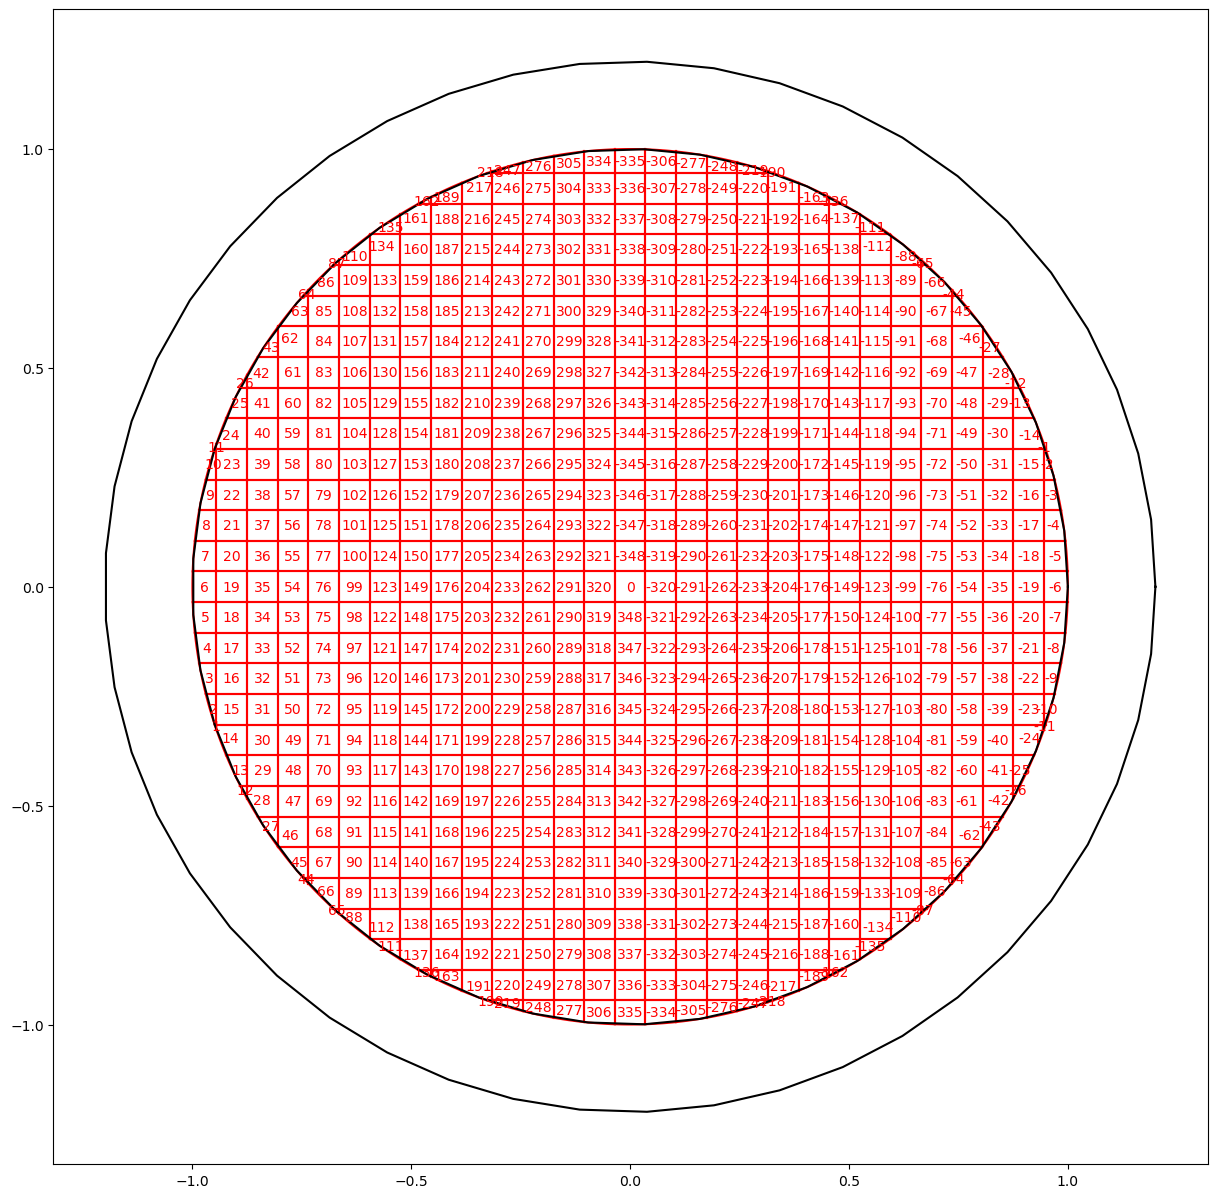

In [3]:
# Loading data
simulation_name = "memory_effect_rectangular"
base_path = Path("/mnt/raid/rmt/data/")
pm = MatrixPoolManager(simulation_name, base_path)

S_matrix_path = Path("/home/nbyrnes/code/random-matrix/rmt_analysis/S.npy")

with open(pm.input_statistics_paths.mode_grid, "rb") as f:
    my_grid = pickle.load(f)

if S_matrix_path.exists():
    S = np.load(S_matrix_path)
else:
    S = pm.S_sampler(1, use_cupy=False, symmetrize=False, random_only=True)[0]
    np.save(S_matrix_path, S)

my_grid.plot(show_indices=True, figsize=(15, 15))

In [4]:
grid_spacing = (my_grid.by_index(-320).center - my_grid.by_index(0).center)[0]

In [5]:
# generate icident field for choice of mode indices
list_inc_modes = [
    0,
    -320,
    -291,
    -262,
    -233,
    -204,
    -176,
    -149,
    -123,
    -99,
    -76,
    -54,
    -35,
    -19,
]
list_inc_modes = [0, -320, -291, -262, -233, -204]
list_inc_modes = [0, -348]
incident_polarization = np.array(
    [np.array([1, 0]) for _ in range(len(list_inc_modes))]
)
incident_polarization = np.array([np.array([1, 0]), np.array([0, 1])])
# Incident field
E_inc = generate_field_tp(
    list_inc_modes, my_grid.num_propagating, incident_polarization
)
E_theta_inc = E_inc[:, 0::2]
E_phi_inc = E_inc[:, 1::2]
I_inc = np.abs(E_theta_inc) ** 2 + np.abs(E_phi_inc) ** 2

# Scattered field calculation
t = matrix_utils.get_block(S, "t")
E_sca = (t @ E_inc.T).T
E_theta_sca = E_sca[:, 0::2]
E_phi_sca = E_sca[:, 1::2]
I_sca = np.abs(E_theta_sca) ** 2 + np.abs(E_phi_sca) ** 2

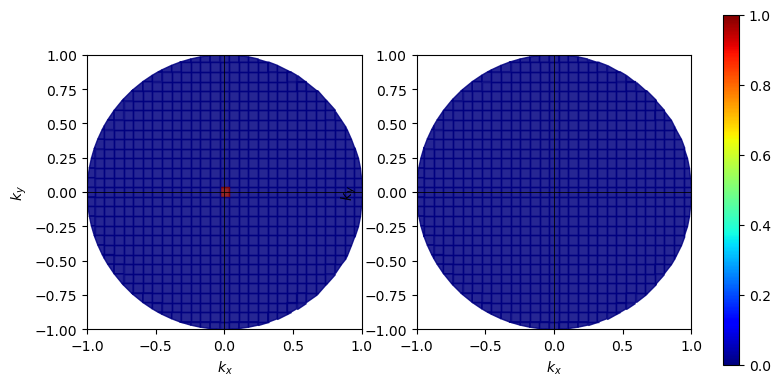

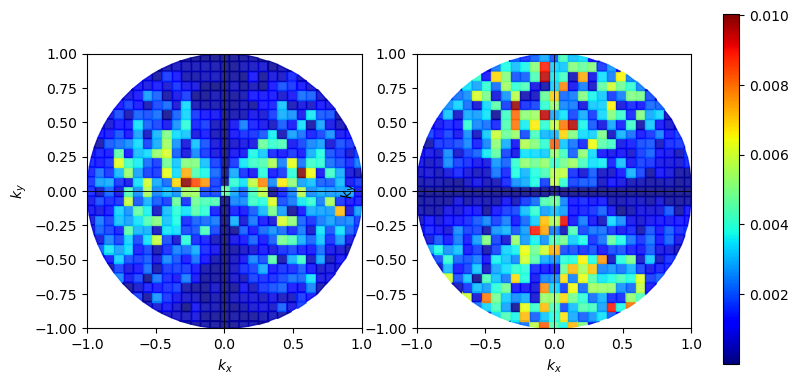

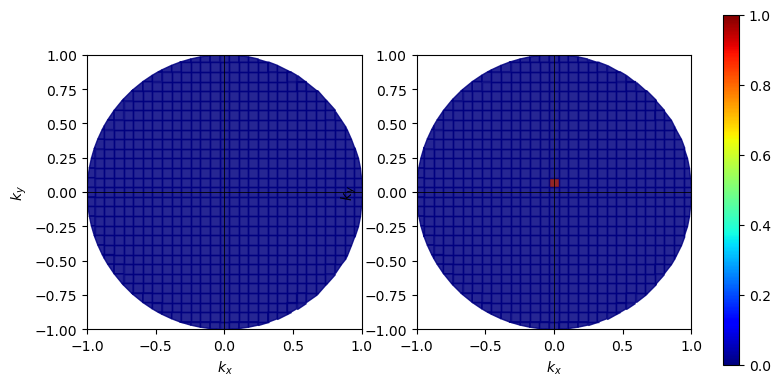

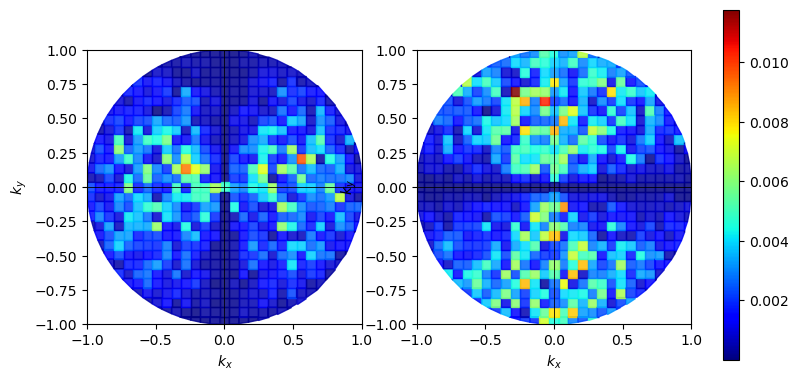

In [6]:
for plot_incident_index in list_inc_modes:
    multi_plot_grid(
        my_grid,
        np.array(
            [
                np.abs(E_theta_inc)[list_inc_modes.index(plot_incident_index)],
                np.abs(E_phi_inc)[list_inc_modes.index(plot_incident_index)],
            ]
        ),
    )
    multi_plot_grid(
        my_grid,
        np.array(
            [
                np.abs(E_theta_sca)[list_inc_modes.index(plot_incident_index)],
                np.abs(E_phi_sca)[list_inc_modes.index(plot_incident_index)],
            ]
        ),
    )


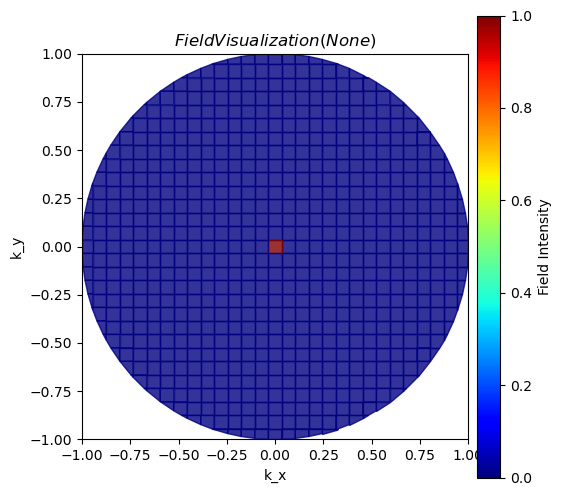

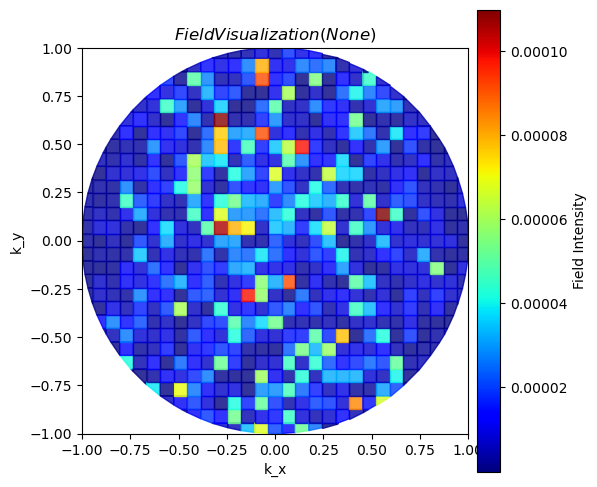

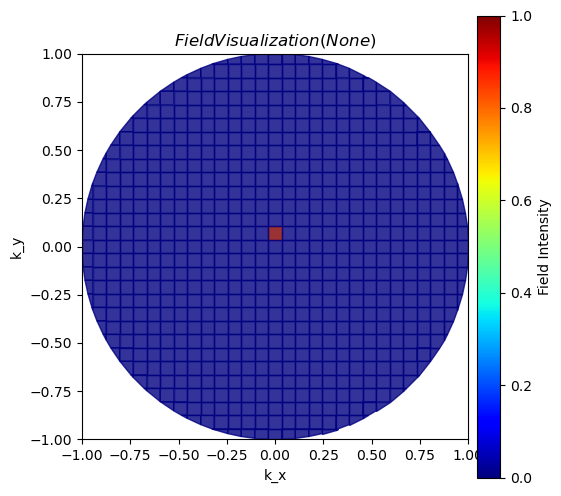

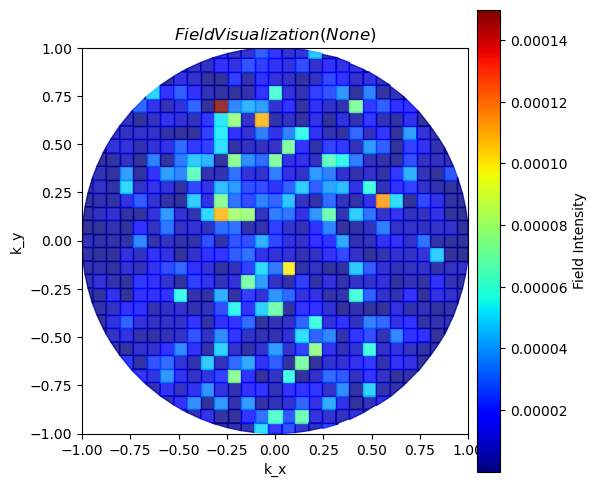

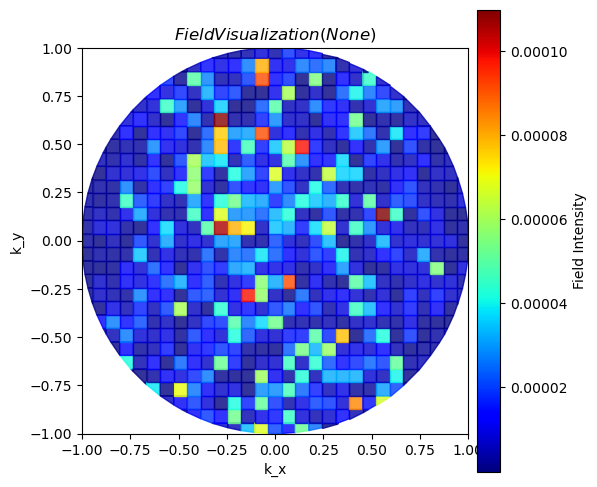

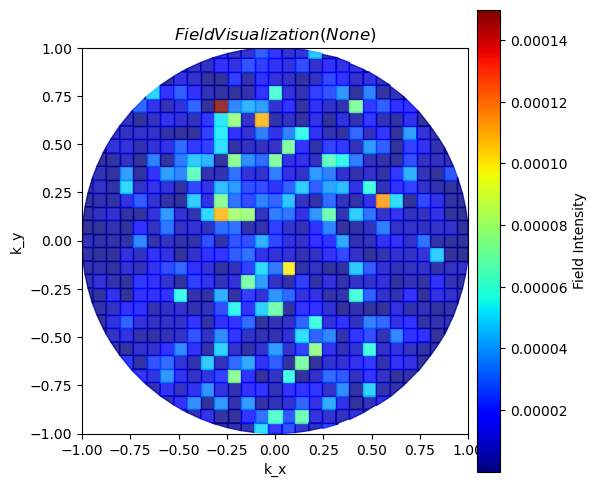

In [7]:
for plot_incident_index in list_inc_modes:
    plot_field_on_grid(my_grid, I_inc[list_inc_modes.index(plot_incident_index)])
    plot_field_on_grid(my_grid, I_sca[list_inc_modes.index(plot_incident_index)])

plot_field_on_grid(my_grid, I_sca[0])
plot_field_on_grid(my_grid, I_sca[1])

/tmp/ipykernel_649651/3732829451.py:25: RuntimeWarning: invalid value encountered in divide
  e_phi /= mod_kappa[..., xp.newaxis]
/tmp/ipykernel_649651/3732829451.py:41: RuntimeWarning: invalid value encountered in divide
  e_theta /= xp.sqrt(


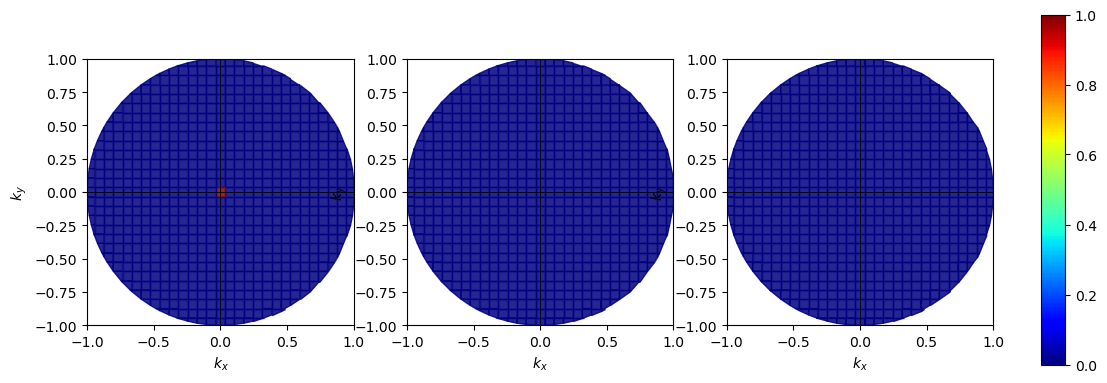

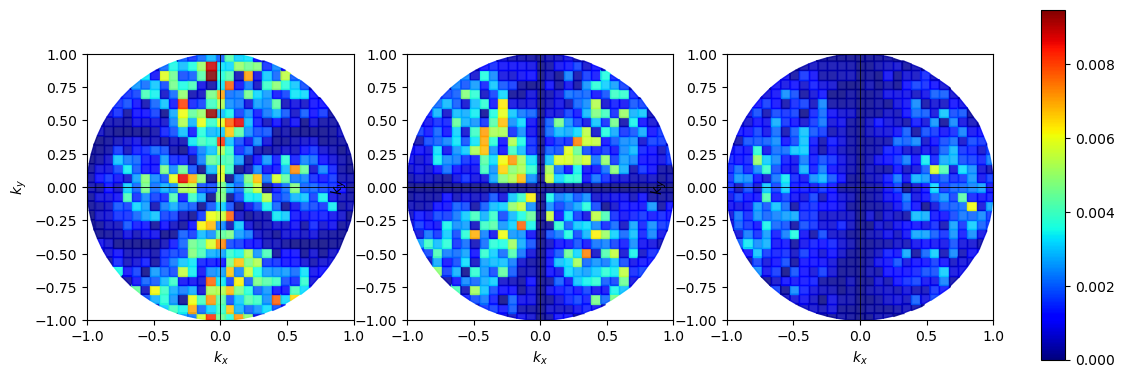

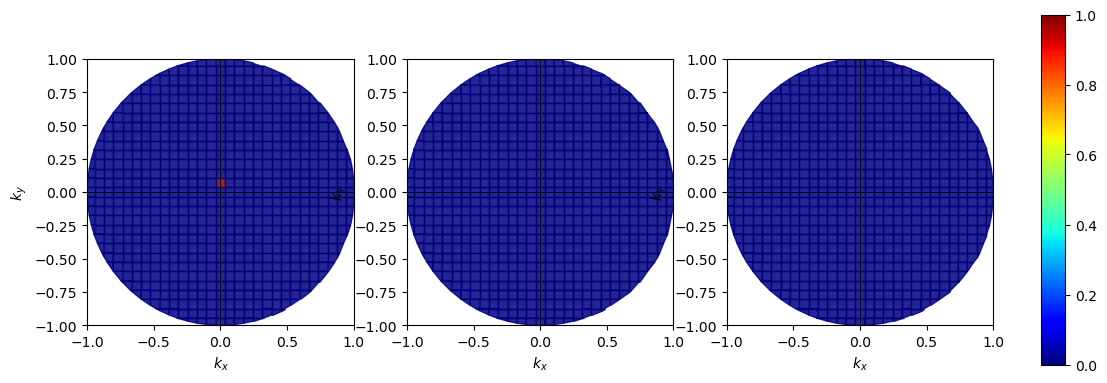

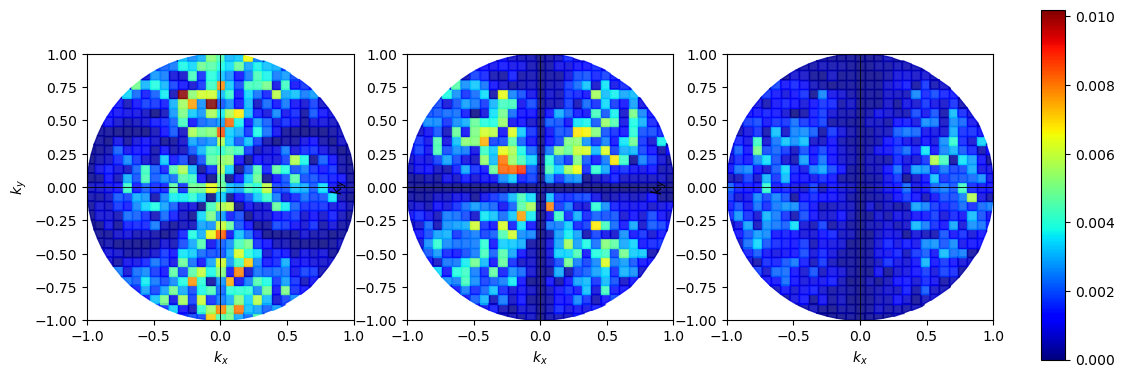

In [8]:
E_kx_inc, E_ky_inc, E_kz_inc = get_xyz_from_tp(my_grid, E_theta_inc, E_phi_inc)
E_kx_sca, E_ky_sca, E_kz_sca = get_xyz_from_tp(my_grid, E_theta_sca, E_phi_sca)

for plot_incident_index in list_inc_modes:
    multi_plot_grid(
        my_grid,
        np.array(
            [
                np.abs(E_kx_inc)[list_inc_modes.index(plot_incident_index)],
                np.abs(E_ky_inc)[list_inc_modes.index(plot_incident_index)],
                np.abs(E_kz_inc)[list_inc_modes.index(plot_incident_index)],
            ]
        ),
    )
    multi_plot_grid(
        my_grid,
        np.array(
            [
                np.abs(E_kx_sca)[list_inc_modes.index(plot_incident_index)],
                np.abs(E_ky_sca)[list_inc_modes.index(plot_incident_index)],
                np.abs(E_kz_sca)[list_inc_modes.index(plot_incident_index)],
            ]
        ),
    )

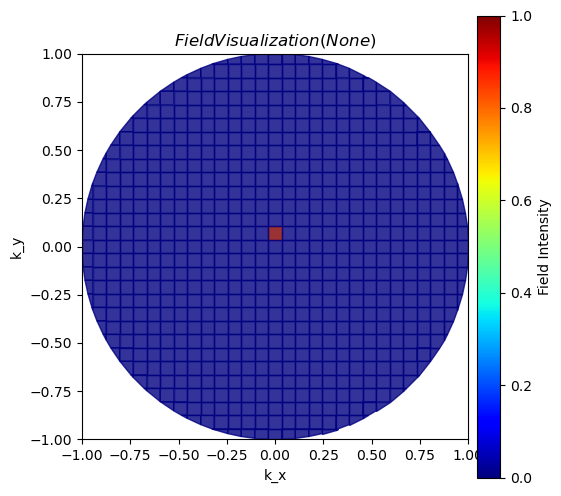

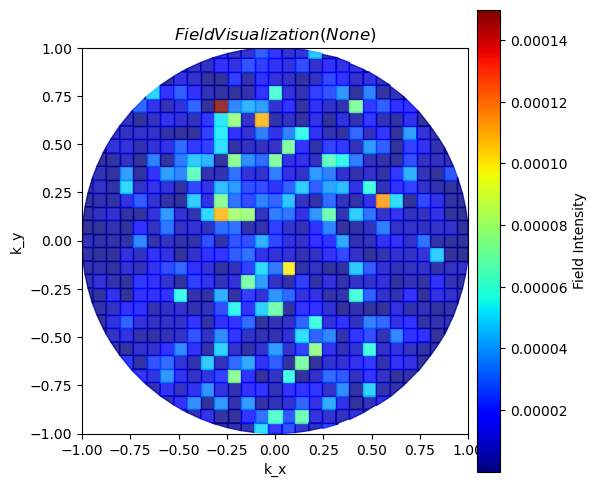

In [9]:
I_xyz_inc = np.abs(E_kx_inc) ** 2 + np.abs(E_ky_inc) ** 2 + np.abs(E_kz_inc) ** 2
I_xyz_sca = np.abs(E_kx_sca) ** 2 + np.abs(E_ky_sca) ** 2 + np.abs(E_kz_sca) ** 2
plot_field_on_grid(my_grid, I_xyz_inc[list_inc_modes.index(plot_incident_index)])
plot_field_on_grid(my_grid, I_xyz_sca[list_inc_modes.index(plot_incident_index)])

In [10]:
wavelength = 550e-9
k = 2 * np.pi / wavelength
z = 0 * wavelength
center_list = [mode.center for mode in my_grid.propagating_modes_list]
center_kz = np.array(
    [np.sqrt(1.0 - np.linalg.norm(center) ** 2) for center in center_list]
)
E_kx_sca_propagated = (
    E_kx_sca * np.exp(1j * k * center_kz * z) * 1 / np.sqrt(center_kz)
)
E_ky_sca_propagated = (
    E_ky_sca * np.exp(1j * k * center_kz * z) * 1 / np.sqrt(center_kz)
)
E_kz_sca_propagated = (
    E_kz_sca * np.exp(1j * k * center_kz * z) * 1 / np.sqrt(center_kz)
)

100%|██████████| 697/697 [00:02<00:00, 262.44it/s]


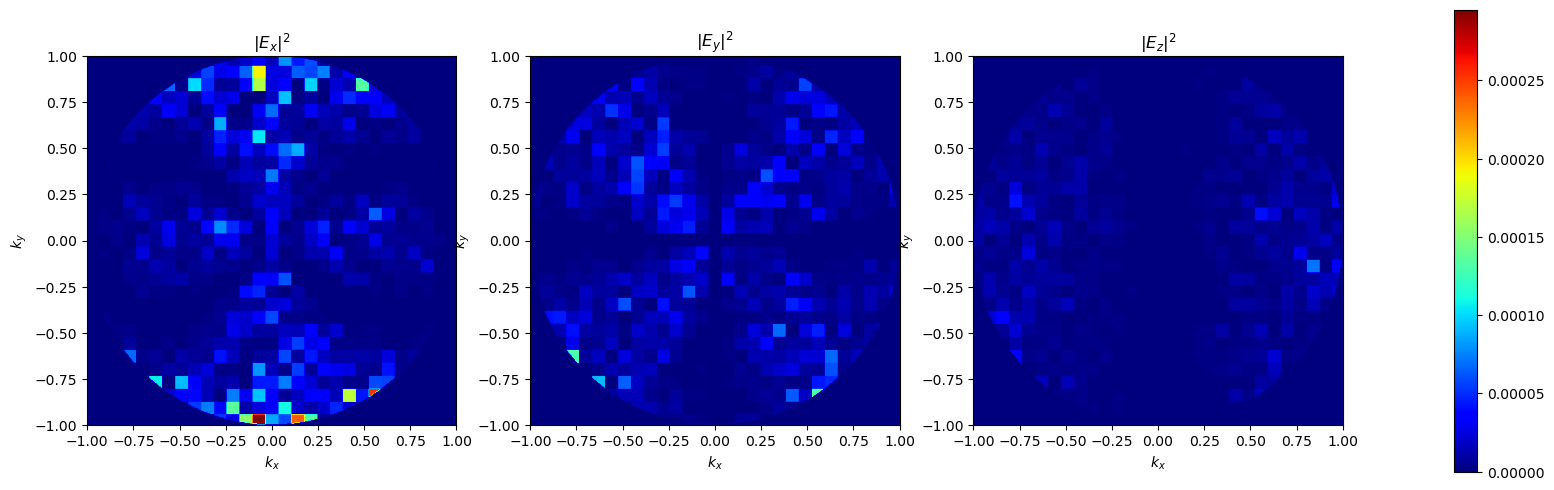

In [11]:
# sca_index is just which incident mode are we picking out
sca_index = 0
E_kx_mesh, E_ky_mesh, E_kz_mesh = grid_2_mesh(
    my_grid,
    E_kx_sca_propagated[sca_index, :],
    E_ky_sca_propagated[sca_index, :],
    E_kz_sca_propagated[sca_index, :],
)


fig, axs = plt.subplots(1, 3, figsize=(18, 6))

fields = [np.abs(E_kx_mesh) ** 2, np.abs(E_ky_mesh) ** 2, np.abs(E_kz_mesh) ** 2]
titles = ["$|E_x|^2$", "$|E_y|^2$", "$|E_z|^2$"]

# Find common color limits
vmin = min(field.min() for field in fields)
vmax = max(field.max() for field in fields)

for i, ax in enumerate(axs):
    im = ax.imshow(
        fields[i],
        extent=[-1, 1, -1, 1],
        cmap="jet",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(titles[i])
    ax.set_xlabel("$k_x$")
    ax.set_ylabel("$k_y$")

# Add a single colorbar for all plots
fig.colorbar(im, ax=axs, orientation="vertical", fraction=0.02, pad=0.08)


100%|██████████| 697/697 [00:03<00:00, 222.06it/s]


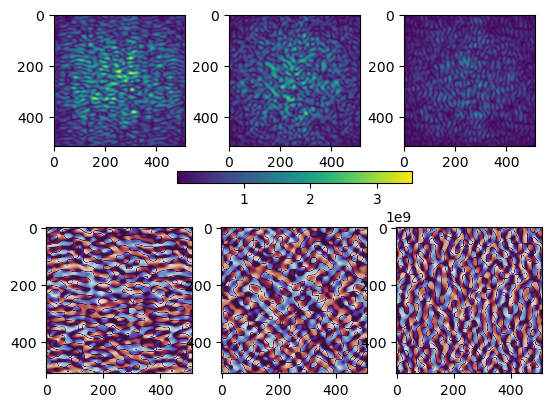

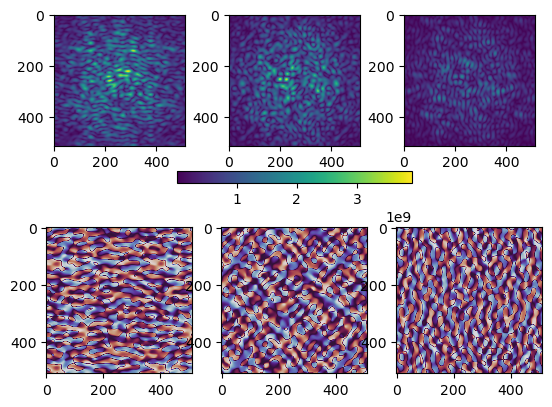

In [15]:
# Convert to real space using CZT
values = {"x": [], "y": [], "z": []}

factor = 10
x_min = -factor * wavelength
x_max = factor * wavelength
y_min = -factor * wavelength
y_max = factor * wavelength

Nx = 512
Nkx = 512
Nk = 512

for i in range(len(list_inc_modes)):
    E_kx_mesh, E_ky_mesh, E_kz_mesh = grid_2_mesh(
        my_grid,
        E_kx_sca_propagated[i, :],
        E_ky_sca_propagated[i, :],
        E_kz_sca_propagated[i, :],
        Nkx=Nkx,
    )
    E_x = czt2(
        E_kx_mesh,
        mode="IFT",
        kscale=k,
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        Nk=Nk,
        Nx=Nx,
    )
    E_y = czt2(
        E_ky_mesh,
        mode="IFT",
        kscale=k,
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        Nk=Nk,
        Nx=Nx,
    )
    E_z = czt2(
        E_kz_mesh,
        mode="IFT",
        kscale=k,
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        Nk=Nk,
        Nx=Nx,
    )
    intensity = np.abs(E_x) ** 2 + np.abs(E_y) ** 2 + np.abs(E_z) ** 2
    abs_arrays = [np.abs(E_x), np.abs(E_y), np.abs(E_z)]
    vmin = min(a.min() for a in abs_arrays)
    vmax = max(a.max() for a in abs_arrays)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.viridis

    fig, ax = plt.subplots(2, 3)
    im0 = ax[0, 0].imshow(np.abs(E_x), cmap=cmap, norm=norm)
    im1 = ax[0, 1].imshow(np.abs(E_y), cmap=cmap, norm=norm)
    im2 = ax[0, 2].imshow(np.abs(E_z), cmap=cmap, norm=norm)

    # ----- Phase plots (use default scaling) -----
    ax[1, 0].imshow(np.angle(E_x), cmap="twilight")
    ax[1, 1].imshow(np.angle(E_y), cmap="twilight")
    ax[1, 2].imshow(np.angle(E_z), cmap="twilight")

    # ----- ONE shared colorbar for magnitudes -----
    fig.colorbar(im0, ax=ax[0, :], orientation="horizontal", fraction=0.07)
    values["x"].append(E_x)
    values["y"].append(E_y)
    values["z"].append(E_z)

(-0.5, 511.5, 511.5, -0.5)

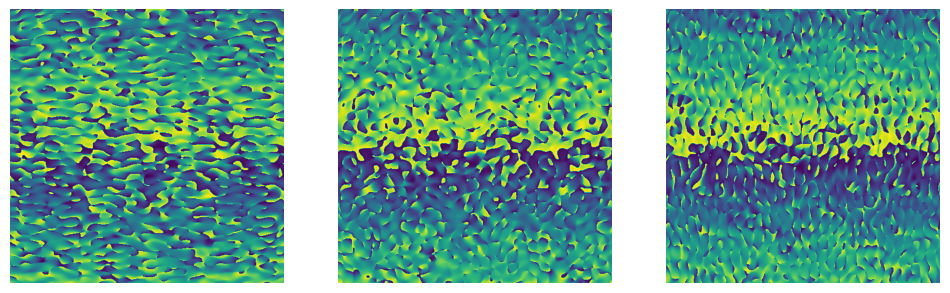

In [16]:
fig, ax = plt.subplots(1,3,figsize=(12,12))
ax[0].imshow(np.angle(values["x"][1]/values["x"][0]))
ax[1].imshow(np.angle(values["y"][1]/values["y"][0]))
ax[2].imshow(np.angle(values["z"][1]/values["z"][0]))
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')  # remove ticks, labels, spines


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

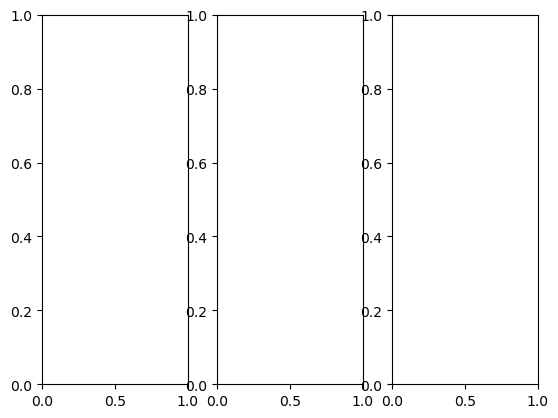

In [14]:
fig, ax = plt.subplots(len(list_inc_modes) - 1,3)
for i in range(len(list_inc_modes) - 1):
    ax[i,0].imshow(np.angle(values["x"][i+1]/values["x"][0]))
    ax[i,1].imshow(np.angle(values["y"][i+1]/values["y"][0]))
    ax[i,2].imshow(np.angle(values["z"][i+1]/values["z"][0]))
    ax[i, 0].axis('off')
    ax[i, 1].axis('off')
    ax[i, 2].axis('off')  # remove ticks, labels, spines
plt.subplots_adjust(wspace=0.01, hspace=0.01)  # reduce spacing